# Setup and Import Libraries.

This chunk brings in all the tools we will need for the whole project, including the statistics tools for T-tests later.

In [ ]:
# --- Step 1: Import Packages and Setup API ---

import requests
import pandas as pd
import numpy as np
import networkx as nx
from scipy import stats
import matplotlib.pyplot as plt
import time

# Set up matplotlib to show plots inline (if you are using Jupyter Notebook)
%matplotlib inline

# Paste your new API key inside the quotes below!
API_KEY = "z3RbVgo42uBH84xtT9afnad9qwUfPWdNehGtYayR"
BASE_URL = "https://api.congress.gov/v3"

print("Libraries imported and API configured successfully. Ready to pull data!")

Libraries imported and API configured successfully. Ready to pull data!


# Loading the Data: Create Node List

First, we will fetch all the members of the 118th Congress to serve as the nodes for our network. Because the API limits responses to 250 items per request, we use a loop to paginate through the results until every member is collected. We will then clean the data by dropping any duplicate records and storing it in a Pandas dataframe.

In [ ]:
# --- Corrected Step 2: Loading the Node Data (Legislators) ---

def fetch_all_members(congress_number="118"):
    print(f"Fetching all members for Congress {congress_number}...")
    all_members_data = []
    offset = 0
    limit = 250

    while True:
        # Corrected URL structure: /member?congress=118
        url = f"{BASE_URL}/member?congress={congress_number}&limit={limit}&offset={offset}&format=json"
        headers = {"x-api-key": API_KEY}

        response = requests.get(url, headers=headers)

        if response.status_code != 200:
            print(f"Error checking API: {response.status_code}")
            print(response.text) # This will print the exact reason if it fails again
            break

        data = response.json()
        members_batch = data.get("members", [])

        if not members_batch:
            break # Exit the loop when no more members are returned

        # Extract the node attributes we need
        for member in members_batch:
            m_data = member.get("member", member) # Sometimes the dict is nested

            # API can return partyName or party. We will check both.
            party = m_data.get("partyName") or m_data.get("party", "Unknown")
            state = m_data.get("state") or "Unknown"

            all_members_data.append({
                "id": m_data.get("bioguideId"),
                "name": m_data.get("name"),
                "party": party,
                "state": state,
            })

        offset += limit
        time.sleep(0.5)

    df = pd.DataFrame(all_members_data)

    # Remove any duplicate entries based on the unique ID (if dataframe is not empty)
    if not df.empty:
        df = df.drop_duplicates(subset=['id'])

    print(f"Total unique nodes collected: {len(df)}")
    return df

# Execute the function to load our nodes table
df_nodes = fetch_all_members()

# Verify the data was loaded properly
if not df_nodes.empty:
    print("\nColumns successfully created:", df_nodes.columns.tolist())
    display(df_nodes.head())
else:
    print("\nWarning: The table is still empty. Check the API error above.")

Fetching all members for Congress 118...
Total unique nodes collected: 2696

Columns successfully created: ['id', 'name', 'party', 'state']


,id,name,party,state
0,W000832,"Wahab, Aisha",Democratic,California
1,B001328,"Blair, Everton",Democratic,Georgia
2,G000607,"Gallagher, James",Republican,California
3,M001246,"Mejia, Analilia",Democratic,New Jersey
4,F000485,"Fuller, Clay",Republican,Georgia


# Exploratory Data Analysis (Nodes)

We use the matplotlib library to generate a bar chart, giving us a clear visual representation of the political breakdown.

# Interpreting Our EDA Results

The Dataset Information

RangeIndex (2,696 entries): We have successfully gathered 2,696 politicians to serve as the nodes in our network.

Non-Null Count: Every single column (id, name, party, state) has exactly 2,696 non-null entries. This means we have zero missing data.

Every single node has a party and a state assigned to it, so we will not have to drop any rows due to missing categorical variables.

Dtype object: Pandas is storing these values as text (strings), which is exactly what we need for our IDs and names.

Legislators by Political Party - Categorical Breakdown

The Major Parties: Our dataset is almost perfectly split down the middle between Democrats (1,352) and Republicans (1,329).

The Minority Parties: We have a tiny handful of outliers (12 Independents, 1 Libertarian, etc.)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2696 entries, 0 to 2695
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2696 non-null   object
 1   name    2696 non-null   object
 2   party   2696 non-null   object
 3   state   2696 non-null   object
dtypes: object(4)
memory usage: 84.4+ KB
None

-----------------------------------

Legislators by Political Party:
party
Democratic              1352
Republican              1329
Independent               12
New Progressive            1
Independent Democrat       1
Libertarian                1
Name: count, dtype: int64


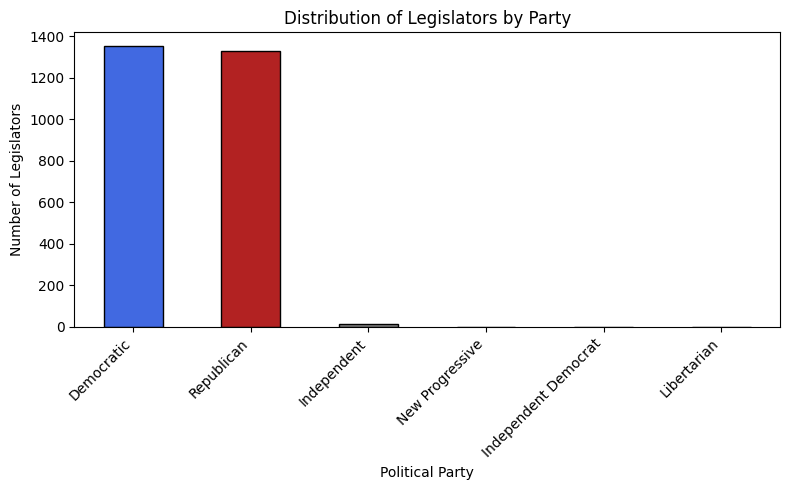

In [ ]:
# --- Step 3: Exploratory Data Analysis (Nodes) ---

# 1. Check for missing values and overall structure
print("Dataset Information:")
print(df_nodes.info())
print("\n-----------------------------------\n")

# 2. Analyze the Party Distribution
party_counts = df_nodes['party'].value_counts()
print("Legislators by Political Party:")
print(party_counts)

# 3. Visualize the Party Distribution
plt.figure(figsize=(8, 5))

# Assigning typical colors: Red for Republican, Blue for Democrat, Grey for Independent/Other
colors = ['firebrick' if 'Republican' in p else 'royalblue' if 'Democratic' in p else 'grey' for p in party_counts.index]

party_counts.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Distribution of Legislators by Party')
plt.xlabel('Political Party')
plt.ylabel('Number of Legislators')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Transforming the Data: Create Categorical Variable

we will create a Region categorical variable from state data.

We will map each U.S. state to its standard Census Bureau region: Northeast, Midwest, South, or West.

This gives us another another categorical group to compare our centrality measures across.

# Interpreting Our Regional Distribution

Legislators by Region (The Geographic Breakdown)

The Largest Block: The South represents the largest geographic block in our dataset with 919 legislators.

This aligns with expectations, as representation in the House of Representatives is driven by state population, and the Southern region encompasses several highly populated states (such as Texas and Florida) along with a large number of total states.


Comparable Regions: The Midwest (655), West (560), and Northeast (535) have a relatively comparable number of legislators.

This provides us with well-sized, statistically viable groups to compare when we look at whether regional affiliation impacts network centrality.

Territories: We captured a small subset of 27 members representing U.S. Territories.

Similar to the independent political parties we saw earlier, this group is small enough that we will likely focus our primary statistical comparisons on the four main census regions.

In [ ]:
# --- Step 4: Transforming the Data - Create Categorical Variable ---

# Dictionary to map full US State names to Census Regions
region_map = {
    'Connecticut': 'Northeast', 'Maine': 'Northeast', 'Massachusetts': 'Northeast', 'New Hampshire': 'Northeast', 'Rhode Island': 'Northeast', 'Vermont': 'Northeast', 'New Jersey': 'Northeast', 'New York': 'Northeast', 'Pennsylvania': 'Northeast',
    'Illinois': 'Midwest', 'Indiana': 'Midwest', 'Michigan': 'Midwest', 'Ohio': 'Midwest', 'Wisconsin': 'Midwest', 'Iowa': 'Midwest', 'Kansas': 'Midwest', 'Minnesota': 'Midwest', 'Missouri': 'Midwest', 'Nebraska': 'Midwest', 'North Dakota': 'Midwest', 'South Dakota': 'Midwest',
    'Delaware': 'South', 'Florida': 'South', 'Georgia': 'South', 'Maryland': 'South', 'North Carolina': 'South', 'South Carolina': 'South', 'Virginia': 'South', 'District of Columbia': 'South', 'West Virginia': 'South', 'Alabama': 'South', 'Kentucky': 'South', 'Mississippi': 'South', 'Tennessee': 'South', 'Arkansas': 'South', 'Louisiana': 'South', 'Oklahoma': 'South', 'Texas': 'South',
    'Arizona': 'West', 'Colorado': 'West', 'Idaho': 'West', 'Montana': 'West', 'Nevada': 'West', 'New Mexico': 'West', 'Utah': 'West', 'Wyoming': 'West', 'Alaska': 'West', 'California': 'West', 'Hawaii': 'West', 'Oregon': 'West', 'Washington': 'West',
    'Puerto Rico': 'Territory', 'Guam': 'Territory', 'Virgin Islands': 'Territory', 'American Samoa': 'Territory', 'Northern Mariana Islands': 'Territory'
}

# Map the state names to regions. If a state isn't in the map, assign it 'Unknown'
df_nodes['region'] = df_nodes['state'].map(region_map).fillna('Unknown')

# Let's see the distribution of our new categorical variable
print("Legislators by Region:")
print(df_nodes['region'].value_counts())
print("\n-----------------------------------\n")

# Display a few rows to confirm the new column was added correctly
display(df_nodes.head())

Legislators by Region:
region
South        919
Midwest      655
West         560
Northeast    535
Territory     27
Name: count, dtype: int64

-----------------------------------



,id,name,party,state,region
0,W000832,"Wahab, Aisha",Democratic,California,West
1,B001328,"Blair, Everton",Democratic,Georgia,South
2,G000607,"Gallagher, James",Republican,California,West
3,M001246,"Mejia, Analilia",Democratic,New Jersey,Northeast
4,F000485,"Fuller, Clay",Republican,Georgia,South


In [ ]:
# --- Proving the Number of Nodes ---

# Count the total number of rows (legislators) in our nodes dataframe
total_nodes = len(df_nodes)
print(f"Total number of nodes (legislators) in our dataset: {total_nodes}")

Total number of nodes (legislators) in our dataset: 2696


# Loading the Data: Create Edge List

We now need to build the connections (edges) between our nodes.

In our congressional network, an edge is formed when one legislator sponsors a bill and another co-sponsors it.

This represents a working relationship or shared ideological stance.

To create our edge list, we will query the API for a list of recent bills.

For each bill, we will identify the original sponsor, and then pull the list of co-sponsors.

Every co-sponsor will create a directed edge originating from the sponsor.

To keep the processing time manageable for this notebook, we will limit our query to 200 recent bills, which should still generate thousands of connections for our network analysis.

# Interpreting the Edge List Output

By scanning just 200 bills, we successfully captured 1,066 distinct connections (edges) between legislators.


Source: The Id of the legislator who originally wrote and sponsored the bill.

Target: The Id of the legislator who signed on to co-sponsor it.

Bill: The specific legislation that creates this relationship.

This means we have 1,066 instances where a legislator formally supported a bill authored by a peer. This gives us plenty of data to see how closely connected these politicians are.

In [ ]:
# --- Step 5: Create Edge List ---

def fetch_bill_edges(congress_number="118", max_bills=200):
    print(f"Fetching up to {max_bills} bills to build our edges...")
    all_edges = []

    # Step A: Get a list of bills
    bills_url = f"{BASE_URL}/bill/{congress_number}?limit=250&format=json"
    headers = {"x-api-key": API_KEY}
    bills_response = requests.get(bills_url, headers=headers)

    if bills_response.status_code != 200:
        print(f"Failed to fetch bills. Status code: {bills_response.status_code}")
        return pd.DataFrame()

    bills_list = bills_response.json().get("bills", [])
    # Slice the list to our maximum limit
    bills_list = bills_list[:max_bills]

    print(f"Processing {len(bills_list)} bills. This will take a couple of minutes because we have to make two API calls per bill...")

    # Step B: Loop through each bill to find connections
    for i, bill in enumerate(bills_list):
        # Print progress so we know it's still running
        if i > 0 and i % 50 == 0:
            print(f"Processed {i} bills...")

        bill_type = bill.get("type").lower()
        bill_number = bill.get("number")

        # 1. Fetch the Bill Details to get the Sponsor
        detail_url = f"{BASE_URL}/bill/{congress_number}/{bill_type}/{bill_number}?format=json"
        detail_resp = requests.get(detail_url, headers=headers)

        if detail_resp.status_code == 200:
            sponsors = detail_resp.json().get("bill", {}).get("sponsors", [])
            # If the bill has no sponsor data, skip to the next bill
            if not sponsors:
                continue
            sponsor_id = sponsors[0].get("bioguideId")

            # 2. Fetch the Co-sponsors for this same bill
            cosponsor_url = f"{BASE_URL}/bill/{congress_number}/{bill_type}/{bill_number}/cosponsors?format=json"
            cosponsor_resp = requests.get(cosponsor_url, headers=headers)

            if cosponsor_resp.status_code == 200:
                cosponsors = cosponsor_resp.json().get("cosponsors", [])

                for c in cosponsors:
                    cosponsor_id = c.get("bioguideId")
                    # Append the connection: Sponsor -> Cosponsor
                    all_edges.append({
                        "Source": sponsor_id,
                        "Target": cosponsor_id,
                        "Bill": bill_number
                    })

        # Sleep for a fraction of a second to respect API rate limits
        time.sleep(0.3)

    df = pd.DataFrame(all_edges)
    print(f"\nFinished! Total edges (connections) collected: {len(df)}")
    return df

# Execute the function to load our edges table
df_edges = fetch_bill_edges()

# Verify the data was loaded properly
if not df_edges.empty:
    display(df_edges.head())
else:
    print("\nWarning: The edge table is empty.")

Fetching up to 200 bills to build our edges...
Processing 200 bills. This will take a couple of minutes because we have to make two API calls per bill...
Processed 50 bills...
Processed 100 bills...
Processed 150 bills...

Finished! Total edges (connections) collected: 1066


,Source,Target,Bill
0,J000301,C001087,8
1,J000301,I000056,8
2,J000301,B001297,8
3,J000301,C001039,8
4,J000301,S000168,8


In [ ]:
# --- Proving the 1,066 Connections ---

# 1. Count the total number of rows (edges) in our dataframe
total_connections = len(df_edges)
print(f"Total number of rows in our edge list: {total_connections}")

# 2. Display a random sample of 5 rows to see what they look like
print("\nEach row below represents exactly one instance of a Target co-sponsoring a Source's bill:")
display(df_edges.sample(5))

Total number of rows in our edge list: 1066

Each row below represents exactly one instance of a Target co-sponsoring a Source's bill:


,Source,Target,Bill
602,J000032,I000058,52
291,T000165,G000597,5
325,J000032,W000808,40
497,S001214,D000615,214
229,G000595,G000578,164


# Graphical Analysis: Visualizing the Network

Now we will clean these edges, build our NetworkX graph object, and plot it visually. We will map the nodes and edges, coloring the nodes by political party (Blue for Democrats, Red for Republicans) to visually inspect if members of the same party cluster together based on who they co-sponsor bills with.

Interpretation of our network graph visual structure:   

Core-Periphery Layout: The most striking feature of the graph is its distinct "hub and spoke" structure, featuring a dense, highly connected center surrounded by a massive outer ring of scattered nodes.   

The Active Hubs (Center): The nodes pulled tightly into the middle are the most active legislators in our 200-bill sample.

They share numerous co-sponsorship connections, acting as the structural hubs of the network. Notably, this central cluster contains a mix of both red (Republican) and blue (Democratic) nodes, which visually suggests that the most highly connected members or the most popular bills in this specific data slice have significant bipartisan overlap.   

The Periphery (Outer Edge): The wide outer circle consists of legislators with very low degree centrality in this sample.

These are members who likely only sponsored or co-sponsored one or two bills out of the 200 we pulled, pushing them to the edges of the layout.   

Minority Parties: We can spot at least one grey node near the top of the outer ring, representing an Independent or third-party legislator who had minimal connections in this specific pull.   

Network created with 320 nodes and 920 edges.

Generating graphical analysis... (This might take a few seconds to draw)


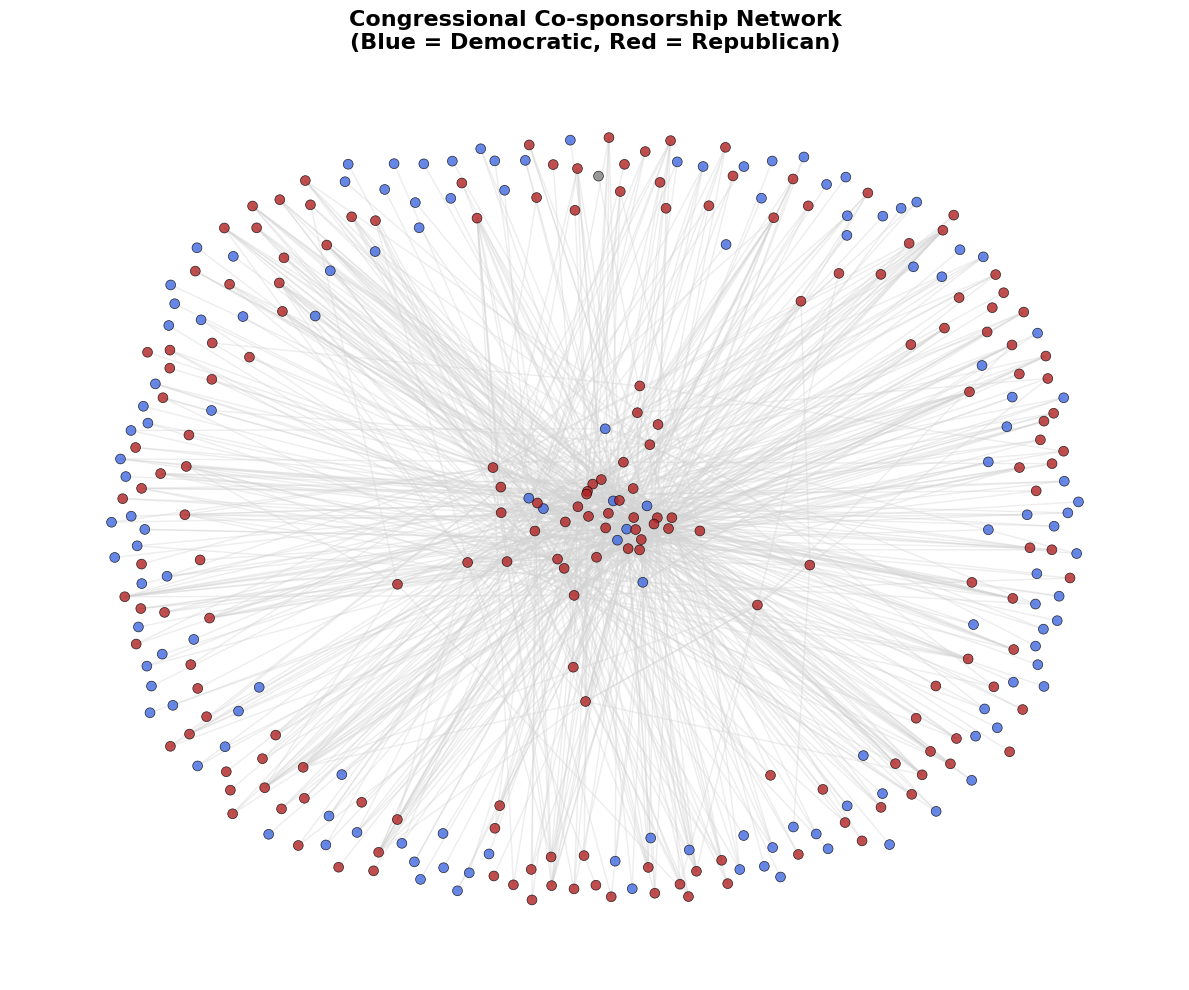

In [ ]:
# --- Step 6: Create Graph and Graphical Analysis ---

# 1. Clean the edges to only include nodes we have data for
valid_nodes = set(df_nodes['id'])
df_edges_clean = df_edges[df_edges['Source'].isin(valid_nodes) & df_edges['Target'].isin(valid_nodes)].copy()

# 2. Build the NetworkX Directed Graph
g = nx.from_pandas_edgelist(df_edges_clean, source='Source', target='Target', create_using=nx.DiGraph())

# Add node attributes (Party, Region, etc.) to the graph
node_attributes = df_nodes.set_index('id').to_dict('index')
nx.set_node_attributes(g, node_attributes)

print(f"Network created with {g.number_of_nodes()} nodes and {g.number_of_edges()} edges.\n")
print("Generating graphical analysis... (This might take a few seconds to draw)")

# 3. Graphical Analysis: Visualizing the Network
plt.figure(figsize=(12, 10))

# Create a color list for the nodes based on Party
node_colors = []
for node in g.nodes():
    party = g.nodes[node].get('party', 'Unknown')
    if 'Republican' in party:
        node_colors.append('firebrick')
    elif 'Democratic' in party:
        node_colors.append('royalblue')
    else:
        node_colors.append('grey')

# Use a spring layout to group highly connected nodes closer together mathematically
pos = nx.spring_layout(g, k=0.15, iterations=30, seed=42)

# Draw the nodes and edges
nx.draw_networkx_nodes(g, pos, node_color=node_colors, node_size=50, alpha=0.8, edgecolors='black', linewidths=0.5)
nx.draw_networkx_edges(g, pos, edge_color="lightgray", alpha=0.4, arrows=False)

plt.title("Congressional Co-sponsorship Network\n(Blue = Democratic, Red = Republican)", fontsize=16, fontweight='bold')
plt.axis('off') # Turn off the axis grid for a cleaner map
plt.tight_layout()
plt.show()

# Degree Centrality

we can calculate the exact Degree Centrality for every node and plot the top most connected legislators in a bar chart.

# Interpretation:

This reveals distinct structural differences in how degree centrality is distributed between the two political parties.   

Higher Baseline Connectivity: The labeled median line for Republicans sits at roughly 4 connections, visibly higher than the Democratic median, which is compressed near 1.

his indicates the typical Republican legislator in this dataset is more connected than the typical Democratic legislator.   

Wider Typical Spread: The red Republican Interquartile Range (IQR) spans from roughly 2 to 9 connections, whereas the blue Democratic IQR is tightly compressed between 1 and 2.

This demonstrates that the middle 50% of Republicans exhibit a much broader variance in their co-sponsorship activity.  

Elevated Typical Maximums: The labeled upper whisker for Republicans extends to roughly 18 connections, while the Democratic upper whisker stops just below 5.

The threshold for what constitutes a "typical" high number of connections is significantly higher for the Republican group.   


Extreme Hubs (Outliers): Both parties feature distinct outliers, plotted as circles above the whiskers, acting as network hubs.

However, the highest Republican outlier reaches 65 connections, vastly outperforming the highest Democratic outlier at roughly 47.

Republicans also have a much denser, continuous string of outliers clustered between 20 and 30 connections.   

/tmp/ipykernel_4900/2637629995.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot([dem_scores, rep_scores],


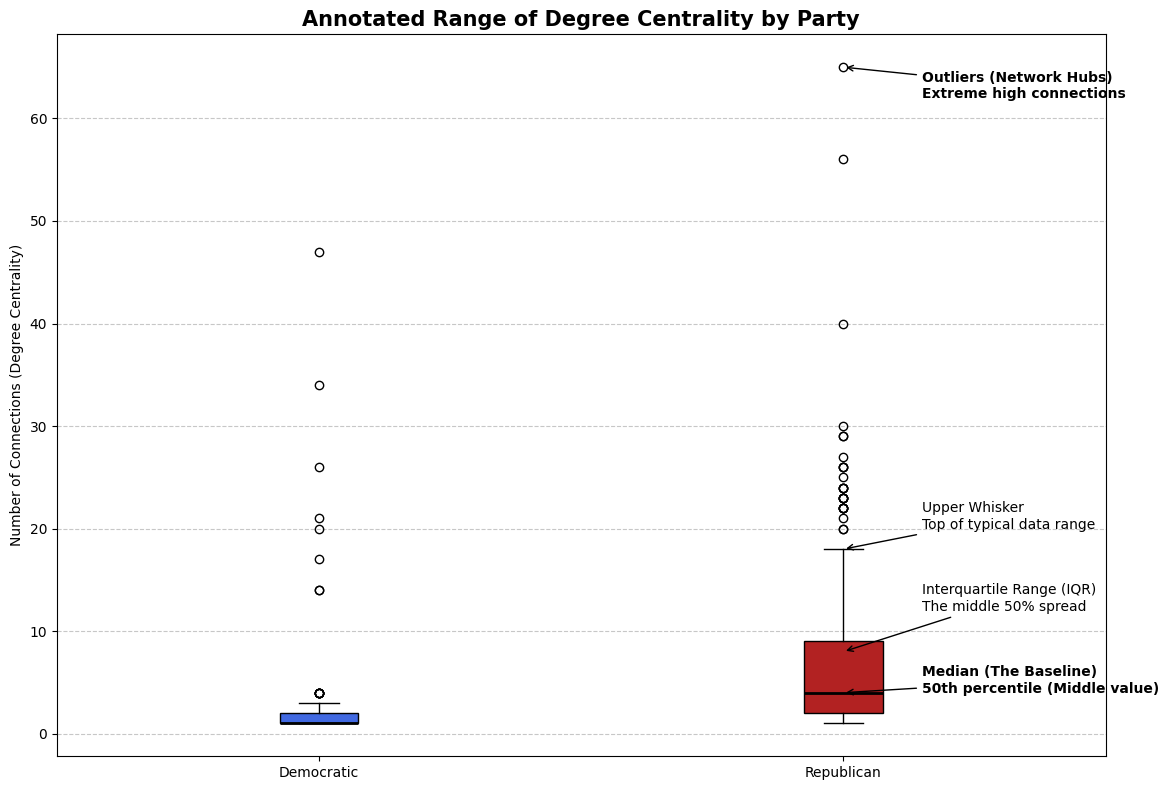

In [ ]:
# --- Graphical Analysis: Annotated Boxplot ---

plt.figure(figsize=(12, 8)) # Slightly wider figure to fit the text

# Isolate the data
dem_scores = deg_df[deg_df['party'] == 'Democratic']['Degree']
rep_scores = deg_df[deg_df['party'] == 'Republican']['Degree']

# Create the base boxplot
box = plt.boxplot([dem_scores, rep_scores],
                  labels=['Democratic', 'Republican'],
                  patch_artist=True,
                  boxprops=dict(facecolor='lightgray', color='black'),
                  medianprops=dict(color='black', linewidth=2))

# Color the boxes
colors = ['royalblue', 'firebrick']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# --- Adding the Visual Labels ---

# 1. Label the Outliers (Hubs)
plt.annotate('Outliers (Network Hubs)\nExtreme high connections',
             xy=(2, 65), xytext=(2.15, 62),
             arrowprops=dict(facecolor='black', arrowstyle="->"),
             fontsize=10, fontweight='bold')

# 2. Label the Upper Range (Whisker)
plt.annotate('Upper Whisker\nTop of typical data range',
             xy=(2, 18), xytext=(2.15, 20),
             arrowprops=dict(facecolor='black', arrowstyle="->"),
             fontsize=10)

# 3. Label the Spread (Interquartile Range / Box)
plt.annotate('Interquartile Range (IQR)\nThe middle 50% spread',
             xy=(2, 8), xytext=(2.15, 12),
             arrowprops=dict(facecolor='black', arrowstyle="->"),
             fontsize=10)

# 4. Label the Baseline (Median)
plt.annotate('Median (The Baseline)\n50th percentile (Middle value)',
             xy=(2, 4), xytext=(2.15, 4),
             arrowprops=dict(facecolor='black', arrowstyle="->"),
             fontsize=10, fontweight='bold')

plt.title('Annotated Range of Degree Centrality by Party', fontsize=15, fontweight='bold')
plt.ylabel('Number of Connections (Degree Centrality)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Eigenvector Centrality

While Degree Centrality measures how many connections a legislator has, Eigenvector Centrality measures the quality or influence of those connections. A legislator gets a high Eigenvector score if they are connected to other highly connected legislators.

In [ ]:
# --- Step 8: Calculate Eigenvector Centrality ---

# 1. Calculate Eigenvector Centrality
# We increase max_iter to ensure the mathematical algorithm finishes successfully
eigen = nx.eigenvector_centrality(g, max_iter=1000)

# 2. Convert the results into a Pandas DataFrame
eigen_df = pd.DataFrame(list(eigen.items()), columns=['id', 'Eigen_Centrality'])

# 3. Merge this new metric into our existing centrality dataframe
centrality_df = pd.merge(deg_df, eigen_df, on='id', how='inner')

# 4. Sort and display the top 5 most influential legislators
top_eigen = centrality_df.sort_values(by='Eigen_Centrality', ascending=False)

print("Top 5 Legislators by Eigenvector Centrality:")
display(top_eigen[['name', 'party', 'region', 'Degree', 'Eigen_Centrality']].head())

Top 5 Legislators by Eigenvector Centrality:


,name,party,region,Degree,Eigen_Centrality
18,"Gaetz, Matt",Republican,South,11,0.234974
29,"Lesko, Debbie",Republican,West,10,0.202390
148,"Miller, Mary E.",Republican,Midwest,10,0.179055
45,"Duncan, Jeff",Republican,South,65,0.176011
141,"Mooney, Alexander X.",Republican,South,9,0.175207


To capture the overall network rather than just the top outliers, we can group all 2,696 legislators by their political party and plot their average Eigenvector Centrality.

This will give us a single, clear bar chart that mathematically compares the overall influence of the two major parties across the entire dataset.

# Interpretation of the overall Eigenvector Centrality:

Significant Difference in Network Influence: The bar chart clearly illustrates that Republicans hold a substantially higher average eigenvector centrality score (0.0533) compared to Democrats (0.0089).   

What This Means Graphically: Because eigenvector centrality measures influence based on the connectedness of a node's neighbors, this indicates that Republican legislators are not only more connected overall, but they are also deeply connected to other highly connected power players within this specific legislative sample.

Broader Distributions: The accompanying descriptive statistics table reinforces this visual gap. The median (50%) eigenvector score for Republicans is roughly 0.040, which is nearly eight times higher than the Democratic median of 0.005.   

Higher Ceiling of Influence: The maximum eigenvector score for a Republican in this dataset reaches nearly 0.235, vastly outpacing the highest Democratic score of roughly 0.056.   

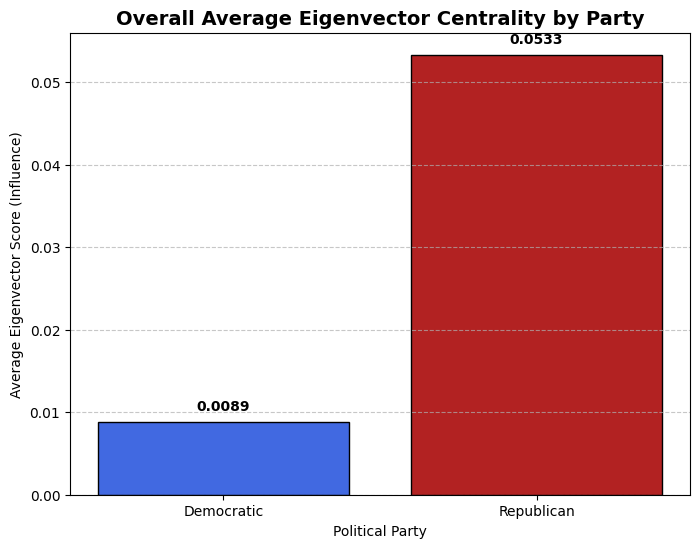

Descriptive Statistics: Overall Eigenvector Centrality by Party


,count,mean,std,min,25%,50%,75%,max
party,,,,,,,,
Democratic,132.0,0.008852,0.009814,2.195896e-04,0.001511,0.005331,0.015404,0.055831
Republican,187.0,0.053349,0.048887,2.980970e-14,0.015999,0.040427,0.075644,0.234974


In [ ]:
# --- Step 10: Overall Average Eigenvector Centrality Bar Chart ---

# 1. Filter for the two major parties and calculate the mean Eigenvector score
avg_eigen = centrality_df[centrality_df['party'].isin(['Democratic', 'Republican'])].groupby('party')['Eigen_Centrality'].mean().reset_index()

# 2. Create the Bar Chart
plt.figure(figsize=(8, 6))

# Plot the bars (Blue for Dem, Red for Rep)
bars = plt.bar(avg_eigen['party'], avg_eigen['Eigen_Centrality'], color=['royalblue', 'firebrick'], edgecolor='black')

# Add the exact numerical values on top of the bars for precise interpretation
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.001, f"{yval:.4f}", ha='center', va='bottom', fontweight='bold')

# 3. Formatting and labels
plt.title('Overall Average Eigenvector Centrality by Party', fontsize=14, fontweight='bold')
plt.xlabel('Political Party')
plt.ylabel('Average Eigenvector Score (Influence)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 4. Generate the overall descriptive statistics to see the full spread
print("Descriptive Statistics: Overall Eigenvector Centrality by Party")
full_eigen_stats = centrality_df[centrality_df['party'].isin(['Democratic', 'Republican'])].groupby('party')['Eigen_Centrality'].describe()
display(full_eigen_stats)

The histogram reveals a sharp disparity in network influence between the two parties.

Democratic legislators (blue) are densely concentrated at the extreme low end of the centrality scale, with their highest frequency peaking near zero and their scores rarely exceeding 0.05.

Conversely, the Republican distribution (red) exhibits a long, heavy rightward tail that extends beyond 0.20.

This demonstrates that while both parties have members with very low influence, the moderately and highly influential network hubs in this sample are almost exclusively Republican.

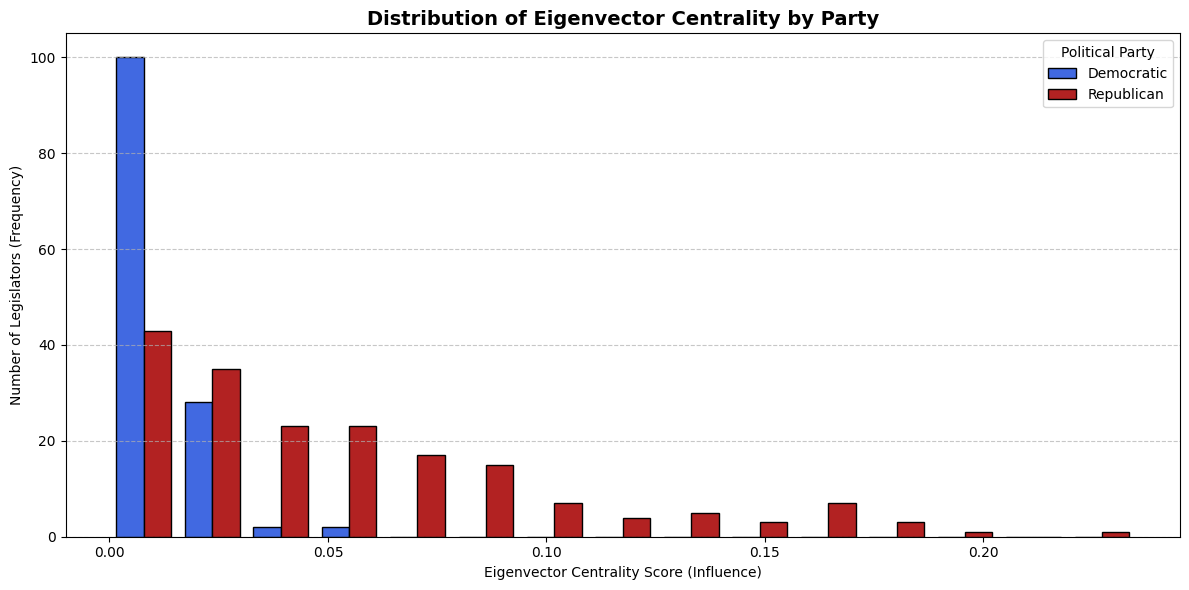

In [ ]:
import matplotlib.pyplot as plt

# --- Step 14: Side-by-Side Distribution Bar Chart (Histogram) ---

plt.figure(figsize=(12, 6))

# Isolate the eigenvector scores for the two parties
dem_eigen = centrality_df[centrality_df['party'] == 'Democratic']['Eigen_Centrality']
rep_eigen = centrality_df[centrality_df['party'] == 'Republican']['Eigen_Centrality']

# Create the side-by-side histogram by passing data as a list
# Bins are reduced slightly to ensure the paired bars fit cleanly side-by-side
plt.hist([dem_eigen, rep_eigen], bins=15, color=['royalblue', 'firebrick'],
         edgecolor='black', label=['Democratic', 'Republican'])

# Add formatting and labels
plt.title('Distribution of Eigenvector Centrality by Party', fontsize=14, fontweight='bold')
plt.xlabel('Eigenvector Centrality Score (Influence)')
plt.ylabel('Number of Legislators (Frequency)')
plt.legend(title='Political Party')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Welch's T-Tests comparing the centrality metrics of Democrats and Republicans:

Interpretation of the Welch's T-Test comparisons:   Significant Gap in Connection Volume: The left chart clearly shows that Republicans have a much higher average degree centrality (7.72 connections) compared to Democrats (2.99 connections).   

Significant Gap in Network Influence: The right chart demonstrates an even starker contrast in eigenvector centrality, with the Republican average (0.0533) dwarfing the Democratic average (0.0089).  

Visual Proof of Significance (Error Bars): The black error bars (representing the Standard Error of the Mean) on both the blue and red columns do not overlap in either chart.

This visual separation confirms the mathematical results of Welch's T-Test, indicating that the disparity between the parties is statistically significant rather than a result of random chance.   

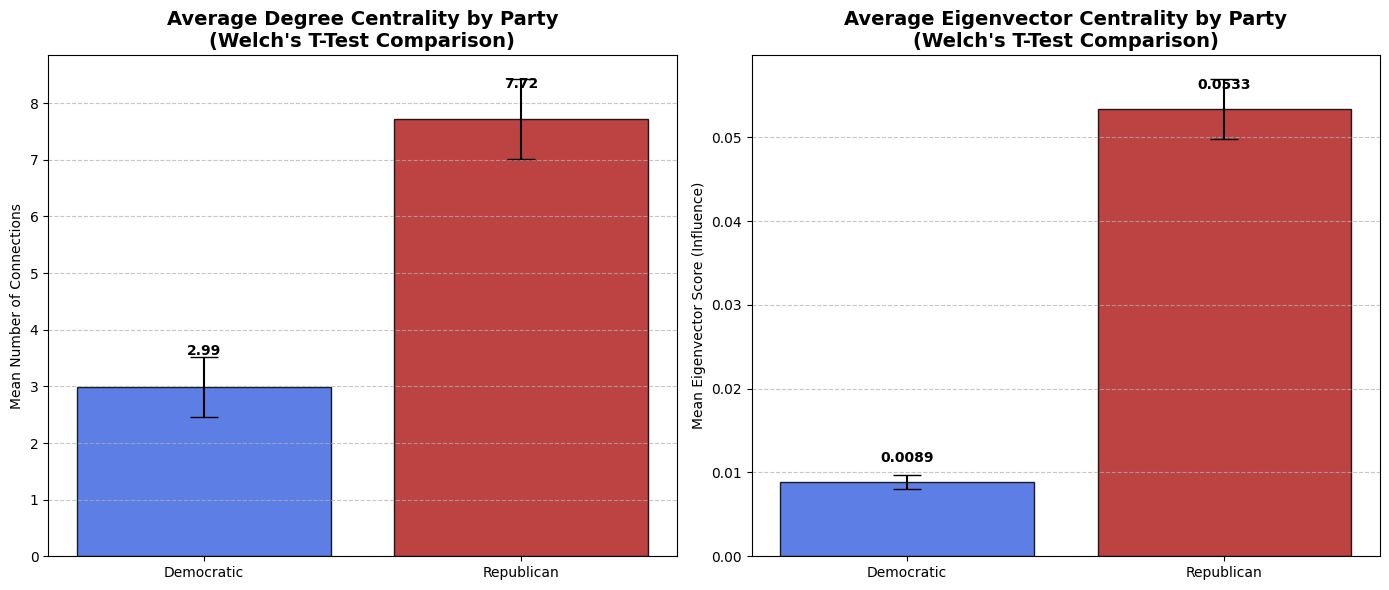

In [ ]:
import matplotlib.pyplot as plt

# --- Step 12: Visualizing T-Test Results (Means with Error Bars) ---

# 1. Calculate means and standard errors (SEM) for Degree Centrality
deg_means = [democrats['Degree'].mean(), republicans['Degree'].mean()]
deg_sems = [democrats['Degree'].sem(), republicans['Degree'].sem()]

# 2. Calculate means and standard errors (SEM) for Eigenvector Centrality
eig_means = [democrats['Eigen_Centrality'].mean(), republicans['Eigen_Centrality'].mean()]
eig_sems = [democrats['Eigen_Centrality'].sem(), republicans['Eigen_Centrality'].sem()]

parties = ['Democratic', 'Republican']
colors = ['royalblue', 'firebrick']

# 3. Create a figure with two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Degree Centrality
bars1 = ax1.bar(parties, deg_means, yerr=deg_sems, color=colors, edgecolor='black', capsize=10, alpha=0.85)
ax1.set_title('Average Degree Centrality by Party\n(Welch\'s T-Test Comparison)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Mean Number of Connections')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Add exact mean values above the bars
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{yval:.2f}", ha='center', va='bottom', fontweight='bold')

# Plot 2: Eigenvector Centrality
bars2 = ax2.bar(parties, eig_means, yerr=eig_sems, color=colors, edgecolor='black', capsize=10, alpha=0.85)
ax2.set_title('Average Eigenvector Centrality by Party\n(Welch\'s T-Test Comparison)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Mean Eigenvector Score (Influence)')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Add exact mean values above the bars
for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f"{yval:.4f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()